In [21]:
import pandas as pd

In [23]:
data = pd.read_csv('/Users/mikeyjensen/Downloads/poi_metrics.csv')

In [25]:
print(data.head)

<bound method NDFrame.head of     session_pitch  session p_throws pitch_type  pitch_speed_mph  \
0          1031_2     1031        R         FF             90.4   
1          1031_3     1031        R         FF             90.4   
2          1097_1     1097        R         FF             77.6   
3          1097_2     1097        R         FF             77.0   
4          1097_3     1097        R         FF             76.1   
..            ...      ...      ...        ...              ...   
406        3252_1     3252        R         FF             80.8   
407        3252_2     3252        R         FF             80.8   
408        3252_3     3252        R         FF             80.8   
409        3252_4     3252        R         FF             83.3   
410        3252_5     3252        R         FF             81.2   

     max_shoulder_internal_rotational_velo  max_elbow_extension_velo  \
0                                4533.2480                 2445.8177   
1                    

In [33]:
pitch_metric = 'max_pelvis_rotational_velo'

In [39]:
#occurunces of number of sessions in column 
session_count = data['session'].value_counts()

In [47]:
max_session = session_count[session_count == 5]

In [49]:
print(max_session)

session
3252    5
2811    5
1808    5
1826    5
1830    5
2653    5
2655    5
2923    5
2734    5
2742    5
2753    5
2760    5
2919    5
2806    5
2812    5
2891    5
2815    5
2818    5
2833    5
2918    5
2843    5
2916    5
2857    5
2859    5
2907    5
2861    5
2865    5
2905    5
2927    5
2935    5
2965    5
2979    5
3248    5
3247    5
3233    5
3232    5
3228    5
3222    5
3172    5
3140    5
3132    5
3065    5
3055    5
3053    5
2889    5
3044    5
3043    5
3037    5
3035    5
3034    5
2999    5
2989    5
Name: count, dtype: int64


In [71]:
filtered_pitch_data = data[data['session'].isin(max_session.index)]

In [73]:
filtered_pitch_data

,session_pitch,session,p_throws,pitch_type,pitch_speed_mph,max_shoulder_internal_rotational_velo,max_elbow_extension_velo,max_torso_rotational_velo,max_rotation_hip_shoulder_separation,max_elbow_flexion,...,rear_grf_z_max,rear_grf_mag_max,rear_grf_angle_at_max,lead_grf_x_max,lead_grf_y_max,lead_grf_z_max,lead_grf_mag_max,lead_grf_angle_at_max,peak_rfd_rear,peak_rfd_lead
89,1808_1,1808,R,FF,81.1,4408.0326,2169.5931,1103.4559,25.7179,118.7212,...,1331.1794,1486.9125,63.5214,1120.7391,223.1800,1963.1937,2260.9515,60.4376,20.3419,70.0859
90,1808_2,1808,R,FF,80.8,4483.7361,2193.8161,1100.0120,27.4708,117.5034,...,1340.9594,1510.0638,60.8025,1102.1394,234.0969,1863.4634,2169.7463,59.4448,27.8995,62.7170
91,1808_3,1808,R,FF,81.3,4321.9842,2120.4270,1072.1819,26.7585,118.2420,...,1314.9542,1483.6668,62.2586,1103.6403,225.9969,1870.2117,2172.1119,59.4603,14.4018,58.8837
92,1808_4,1808,R,FF,81.2,4362.3438,2181.9336,1106.2160,26.0000,122.2713,...,1284.9372,1450.9076,59.5123,1114.6654,257.0216,1978.6942,2276.7604,60.6014,25.7041,59.6118
93,1808_5,1808,R,FF,81.2,4491.4238,2173.5374,1086.8808,27.0232,120.1453,...,1507.9242,1515.3371,87.0539,1060.1505,259.3521,1876.6346,2164.3312,60.5396,54.4717,64.7539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,3252_1,3252,R,FF,80.8,4494.0446,2759.7142,1129.4168,42.9000,123.5448,...,1315.2310,1469.9282,62.5808,864.8566,141.5886,1685.4288,1891.2377,63.0494,6307.8100,72742.9029
407,3252_2,3252,R,FF,80.8,4550.4618,2742.8536,1129.4417,43.5008,123.5490,...,1246.7301,1418.5732,60.7799,921.8930,104.1382,1708.8564,1932.4776,61.7749,7850.2644,77906.1103
408,3252_3,3252,R,FF,80.8,4580.0385,2796.3719,1133.8676,43.7838,125.6560,...,1278.0224,1470.2659,60.8819,874.7938,86.2704,1647.5457,1858.1106,62.8667,16303.1697,77777.3331
409,3252_4,3252,R,FF,83.3,4638.4414,2815.9331,1119.5235,43.0352,127.5534,...,1254.4113,1414.2349,63.4549,841.1043,117.9198,1658.6645,1863.5780,63.3718,11758.9779,77382.0300


In [75]:
std_per_pitcher = filtered_pitch_data.groupby('session')[pitch_metric].std().reset_index()

In [77]:
std_per_pitcher

,session,max_pelvis_rotational_velo
0,1808,30.787943
1,1826,40.373841
2,1830,21.657448
3,2653,18.781352
4,2655,28.345463
5,2734,23.445408
6,2742,44.291192
7,2753,20.192801
8,2760,27.530737
9,2806,12.984320


In [83]:
max_std_row = std_per_pitcher.loc[std_per_pitcher['max_pelvis_rotational_velo'].idxmax()]

In [85]:
max_std_row

session                       2979.000000
max_pelvis_rotational_velo      58.924479
Name: 31, dtype: float64

In [323]:
min_std_row = std_per_pitcher.loc[std_per_pitcher['max_pelvis_rotational_velo'].idxmin()]
avg_std_row = std_per_pitcher.loc[std_per_pitcher['max_pelvis_rotational_velo'].idxmax()]

In [89]:
min_std_row

session                       2806.00000
max_pelvis_rotational_velo      12.98432
Name: 9, dtype: float64

In [91]:
std_per_pitcher_velo = data.groupby('session')['pitch_speed_mph'].std().reset_index()


In [93]:
std_per_pitcher_velo

,session,pitch_speed_mph
0,1031,0.000000
1,1097,0.754983
2,1170,1.202082
3,1250,0.353553
4,1313,0.057735
...,...,...
95,3233,0.517687
96,3247,1.094532
97,3248,0.614003
98,3250,0.531507


In [381]:
avg_per_pitcher_metric = data.groupby('session')['pitch_speed_mph'].std().reset_index()
max_torso_rot_pitcher_metric = data.groupby('session')['max_torso_rotational_velo'].std().reset_index()

In [367]:
max_torso_rot_pitcher_metric

,session,stride_length
0,1031,0.834500
1,1097,0.817833
2,1170,0.871450
3,1250,0.839750
4,1313,0.884467
...,...,...
95,3233,0.903280
96,3247,0.777300
97,3248,0.870100
98,3250,0.883675


In [185]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [383]:
X = std_per_pitcher_velo['pitch_speed_mph']
y = max_torso_rot_pitcher_metric['max_torso_rotational_velo']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

y_pred = model.predict(X)


In [265]:
X

,const,pitch_speed_mph
0,1.0,0.000000
1,1.0,0.754983
2,1.0,1.202082
3,1.0,0.353553
4,1.0,0.057735
...,...,...
95,1.0,0.517687
96,1.0,1.094532
97,1.0,0.614003
98,1.0,0.531507


In [371]:
y

0     0.834500
1     0.817833
2     0.871450
3     0.839750
4     0.884467
        ...   
95    0.903280
96    0.777300
97    0.870100
98    0.883675
99    0.787140
Name: stride_length, Length: 100, dtype: float64

In [199]:
model

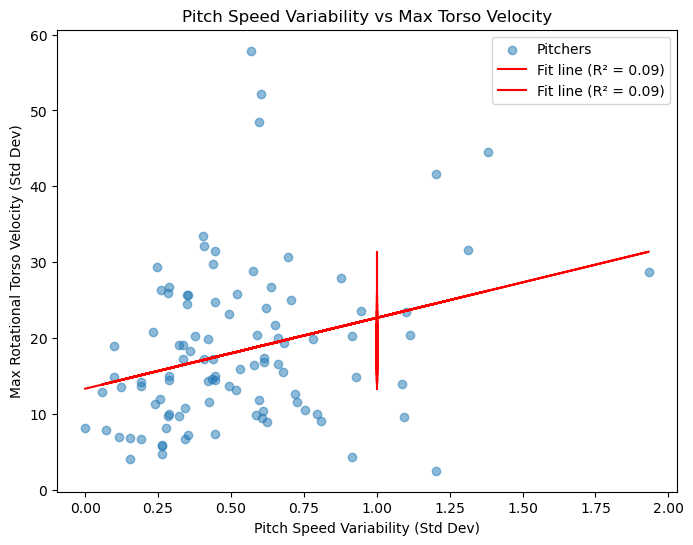

In [405]:
X = std_per_pitcher_velo['pitch_speed_mph']  
y = max_torso_rot_pitcher_metric['max_torso_rotational_velo']  


X = sm.add_constant(X)


model = sm.OLS(y, X).fit()


y_pred = model.predict(X)

r_squared = model.rsquared


plt.figure(figsize=(8, 6))
plt.scatter(X['pitch_speed_mph'], y, label='Pitchers', alpha=0.5) 

plt.plot(X, y_pred, color="red", label=f"Fit line (R² = {r_squared:.2f})")


plt.xlabel('Pitch Speed Variability (Std Dev)')
plt.ylabel('Max Rotational Torso Velocity (Std Dev)')
plt.title('Pitch Speed Variability vs Max Torso Velocity')
plt.legend()
plt.show()